#Task 1: Problem Identification


The given dataset represents an image classification problem, where each image is assigned to one of four predefined categories: normal, scratch, dent, or stain. Each image contains a single dominant label, and there is no requirement to detect object locations or segment specific regions within the image. Therefore, image classification is the most appropriate problem formulation for this dataset.

# Task 2: Dataset Exploration

In [36]:
# Dataset directory check

import os

data_dir = "images"

if not os.path.exists(data_dir):
    print("Dataset folder not found!")
    print("Please download dataset from the link in README and place it in the project directory.")
else:
    print("Dataset found. Proceeding...")

Dataset found. Proceeding...


In [2]:
# Import Libraries
import os
import cv2
import matplotlib.pyplot as plt


Classes: ['dent', 'normal', 'scratch', 'stain']
Number of classes: 4
Image count per class:
dent: 120
normal: 120
scratch: 120
stain: 120
dent image shape: (96, 96, 3)
normal image shape: (96, 96, 3)
scratch image shape: (96, 96, 3)
stain image shape: (96, 96, 3)


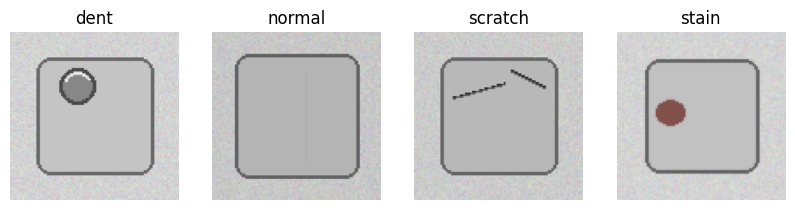

{'dent': 120, 'normal': 120, 'scratch': 120, 'stain': 120}


In [ ]:
# Define dataset path
data_dir = "images"  # or full path if needed
classes = os.listdir(data_dir)

# Number of classes
print("Classes:", classes)
print("Number of classes:", len(classes))

#Count Images per Class
image_counts = {}

for cls in classes:
    class_path = os.path.join(data_dir, cls)
    image_counts[cls] = len(os.listdir(class_path))

print("Image count per class:")
for k, v in image_counts.items():
    print(f"{k}: {v}")

#Image dimensions
for cls in classes:
    class_path = os.path.join(data_dir, cls)
    sample_img = os.listdir(class_path)[0]
    
    img_path = os.path.join(class_path, sample_img)
    img = cv2.imread(img_path)
    
    print(f"{cls} image shape:", img.shape) 

# Sample images from each class
plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    class_path = os.path.join(data_dir, cls)
    img_name = os.listdir(class_path)[0]
    
    img_path = os.path.join(class_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

# Any imbalance in the dataset
print(image_counts)



#Task 3: Image Preprocessing

In [14]:
#Import Libraries

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Resizing images to a fixed size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalization
    validation_split=0.2,    # 80-20 split
    
    # Augmentation
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

# Load training data
train_data = train_datagen.flow_from_directory(
    "images",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# visualize data
val_data = train_datagen.flow_from_directory(
    "images",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_data.class_indices)
print("Number of training samples:", train_data.samples)
print("Number of validation samples:", val_data.samples)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
Class indices: {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}
Number of training samples: 384
Number of validation samples: 96


#Task 4: CNN Model Creation

In [24]:
# import libraries
from tensorflow import keras
from tensorflow.keras import layers

In [28]:
# build cnn model

model = keras.Sequential([
    
    # Input Layer
    keras.Input(shape=(128, 128, 3)),
    
    # 🔹 Convolution Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 🔹 Convolution Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 🔹 Convolution Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten
    layers.Flatten(),
    
    # Dense Layer
    layers.Dense(128, activation='relu'),
    
    # Output Layer (4 classes)
    layers.Dense(4, activation='softmax')
])

model.summary()

# compile model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

#Task 5: Model Training and Evaluation

In [29]:
# train the model

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 508ms/step - accuracy: 0.2552 - loss: 1.5779 - val_accuracy: 0.2500 - val_loss: 1.3826
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 417ms/step - accuracy: 0.3255 - loss: 1.3762 - val_accuracy: 0.2500 - val_loss: 1.3558
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 402ms/step - accuracy: 0.4141 - loss: 1.3085 - val_accuracy: 0.5417 - val_loss: 1.1867
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 405ms/step - accuracy: 0.5755 - loss: 1.0280 - val_accuracy: 0.5833 - val_loss: 0.9116
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 440ms/step - accuracy: 0.6068 - loss: 0.8993 - val_accuracy: 0.5938 - val_loss: 0.9184
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 375ms/step - accuracy: 0.7057 - loss: 0.6960 - val_accuracy: 0.7500 - val_loss: 0.5802
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 439ms/step - accuracy: 0.7865 - loss: 0.4966 - val_accuracy: 0.8229 - val_loss: 0.4567
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 398ms/step - accuracy: 0.8490 - loss: 0.3730 - val_accuracy: 0

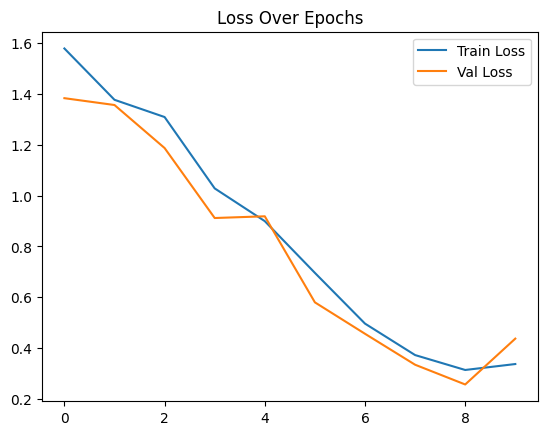

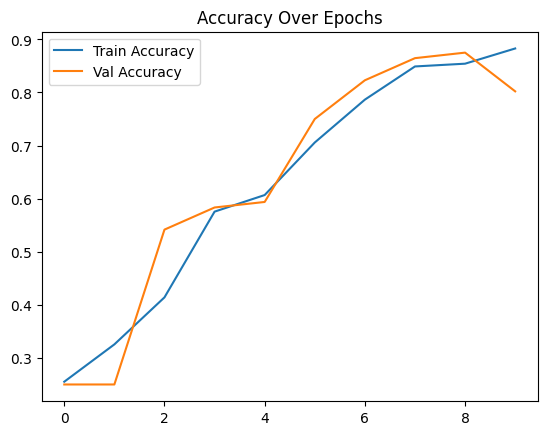

In [30]:
# Plot Training & Validation

import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Over Epochs")
plt.legend()
plt.show()

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Over Epochs")
plt.legend()
plt.show()

In [31]:
# evaluate model on validation
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.8333 - loss: 0.4338
Validation Loss: 0.43380001187324524
Validation Accuracy: 0.8333333134651184


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step
Confusion Matrix:
 [[ 3 11  5  5]
 [ 1  8  7  8]
 [ 4  7  9  4]
 [ 3  5  9  7]]


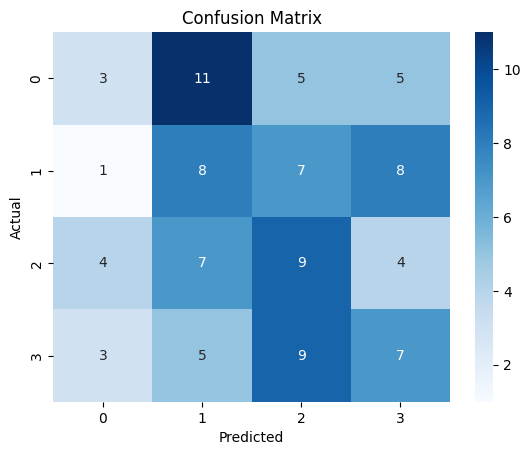

In [32]:
# Confusion Matrix
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predictions
y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = val_data.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

print("Confusion Matrix:\n", cm)

# Plot
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


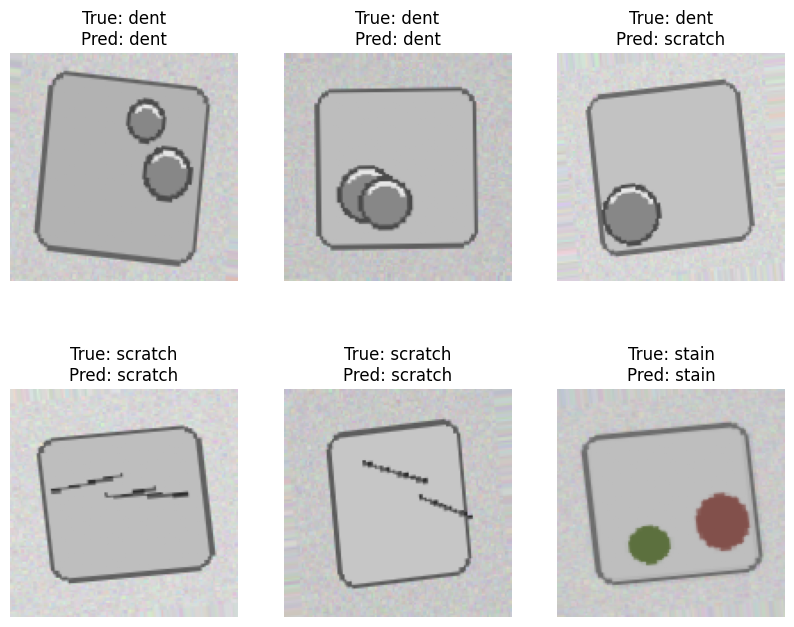

In [34]:
# Sample Prediction

import numpy as np

plt.figure(figsize=(10, 8))

class_names = list(val_data.class_indices.keys())

# Get one batch
images, labels = next(val_data)

for i in range(min(6, len(images))):
    
    img = images[i]
    label = labels[i]
    
    pred = model.predict(np.expand_dims(img, axis=0))
    
    true_label = class_names[np.argmax(label)]
    pred_label = class_names[np.argmax(pred)]
    
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.show()

# Task 7: Business Use Case Mapping

This CNN model can be used in manufacturing for automated defect detection (scratch, dent, stain), improving quality control and reducing manual inspection effort.